In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from scipy.stats import binomtest, ttest_ind, chi2_contingency, chisquare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("train_data.csv")
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
91348,108635,15606267,Wilson,622,France,Female,35.0,7,98640.74,2,1.0,1.0,110457.99,1
2636,147941,15644891,Pirozzi,752,France,Female,32.0,2,0.00,1,1.0,0.0,159843.24,0
117007,88744,15702464,Watson,710,France,Male,31.0,4,0.00,3,0.0,0.0,160548.66,1
100279,125789,15701605,L?,704,Germany,Male,46.0,4,138912.17,1,0.0,1.0,141804.78,1
34835,135997,15757577,Hs?,675,Germany,Female,51.0,8,143390.51,1,1.0,0.0,168034.90,1


In [22]:
train_set["Exited"].value_counts()

Exited
0    90564
1    24299
Name: count, dtype: int64

On voit que les deux classes de la target sont assez désiquilibré et c'est pour cette raison qu'on utilisera la métrique f1_score. On va d'abords utiliser un modéle de régréssion logistique pour un premier modéle.

##I) éfinition des variables

•   Customer ID : Un identifiant unique pour chaque client (discret). Inutile pour le modéle.

•   Surname : Le nom de famille du client (discret). Inutile pour le modéle.

•   Credit Score : Une valeur numérique représentant le score de crédit du client (continue)

•   Geography : Le pays où réside le client (France, Spain ou Germany) (discret)

•   Gender : Le genre du client (Male or Female) (discret)

•   Age : L’âge du client (C'est une variable discréte mais qu'on va traiter comme une variable continue)

•   Tenure : Le nombre d’années pendant lesquelles le client est avec la banque (discret)

•   Balance : Le solde du compte du client (continue)

•   NumOfProducts : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit) (discret)

•   HasCrCard : Si le client possède une carte de crédit (1 = oui, 0 = non) (discret)

•   IsActiveMember : Si le client est un membre actif (1 = oui, 0 = non) (discret)

•   EstimatedSalary : Le salaire estimé du client (continue)

•   Exited : Si le client a résilié (1 = oui, 0 = non) (discret)

•   Pour la définition des lignes, c'est les clients.

##II) Analyse statistiques

Dans cette partie on va redivisée le train set pour éciter le biais de confirmation.

In [23]:
observation_set, confirmation_set = train_test_split(train_set, test_size=0.2, random_state=42)
len(observation_set)

91890

In [24]:
len(confirmation_set)

22973

#1) Analyse univarié

1.1) Analyse des variables discrétes

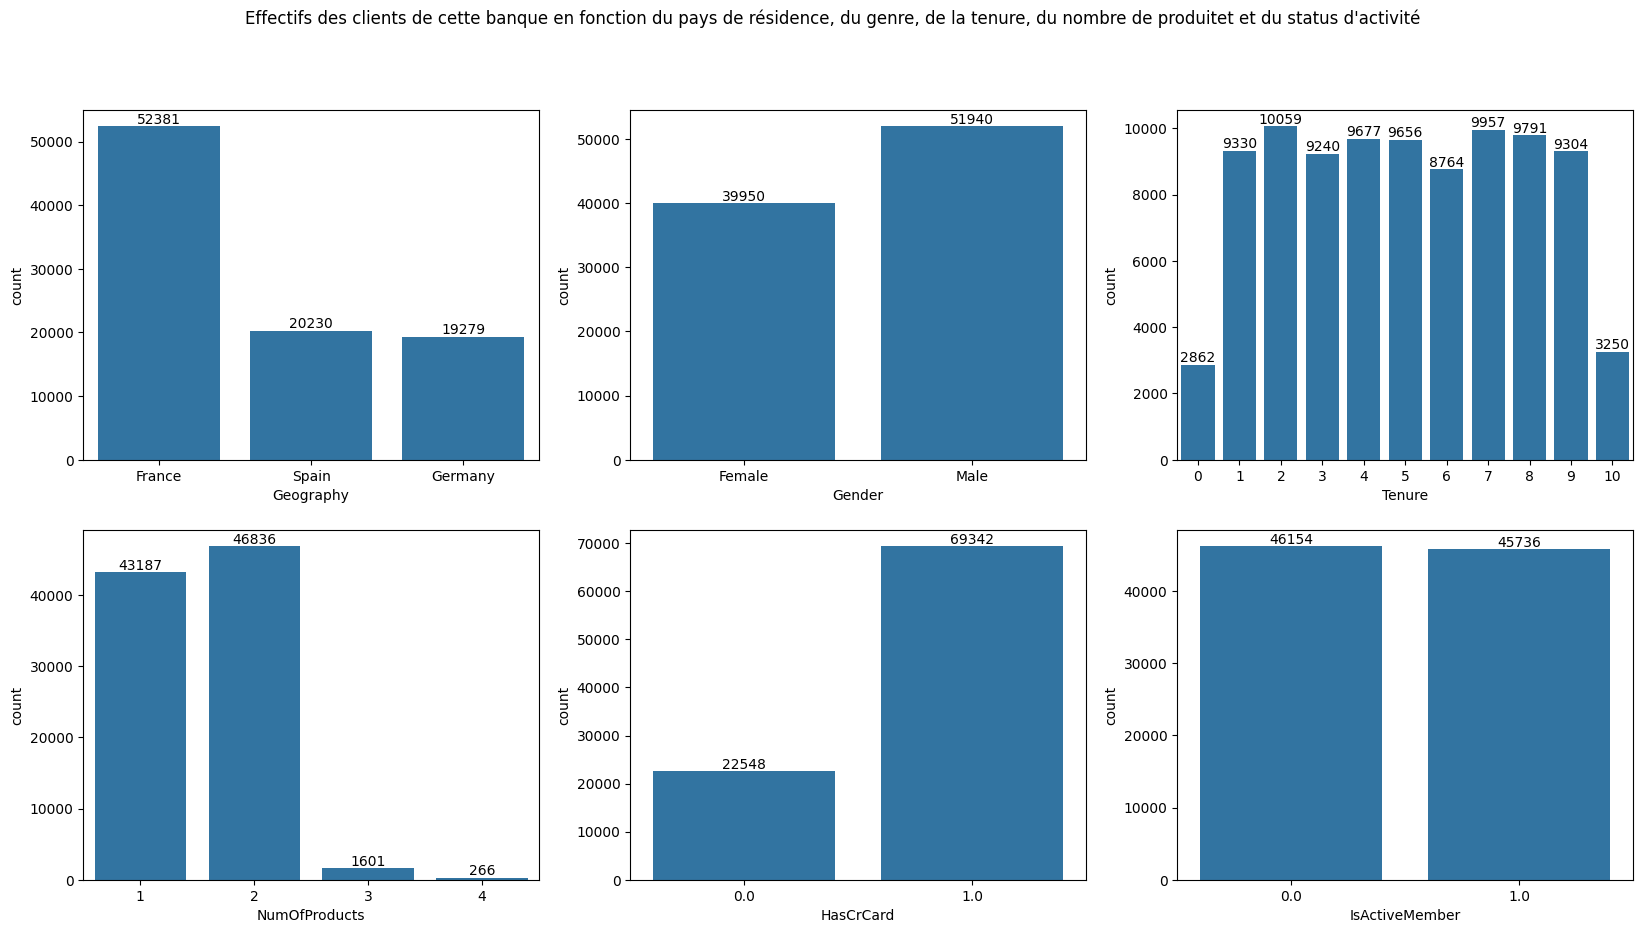

In [25]:
fig, ax = plt.subplots(2, 3)
fig.set_size_inches(20, 10)
plt.suptitle("Effectifs des clients de cette banque en fonction du pays de résidence, du genre, de la tenure, du nombre de produitet et du status d'activité")
sns.countplot(data=observation_set, x="Geography", ax=ax[0,0])
sns.countplot(data=observation_set, x="Gender", ax=ax[0,1])
sns.countplot(data=observation_set, x="Tenure", ax=ax[0,2])
sns.countplot(data=observation_set, x="NumOfProducts", ax=ax[1,0])
sns.countplot(data=observation_set, x="HasCrCard", ax=ax[1,1])
sns.countplot(data=observation_set, x="IsActiveMember", ax=ax[1,2])
for i in range(2):
    for ii in range(3):
        for container in ax[i, ii].containers:
            ax[i, ii].bar_label(container)
plt.show()

On voit que le nombre de client vive majoritairement en France et on a une quantité de client similaires pour l'Allemagne et l'Espagne. Il y a donc une forte chance que la banque soit Française. On remarque qu'il y a plus d'homme que de femmes dans cette banque. On voit que le nombre de client pour une tenure de 0 et 10 est largement inférieur au autres valeurs et ensuite le nombre de client reste relativement constant pour des tenures entre 1 et 9. On voit que les clients ont majoritairement 1 ou 2 produits et trés peu ont 3 et 4 produits. Le nombre de client qui ont 1 et 2 produit sont similaires ainsi que le nombre de client qui ont 3 et 4 produit. On voit que la majorité des clients ont une carte de crédit et qu'il y a pratiquement autant de client qui sont actifs et iniactifs. On va maintenant test toutes nos observations.

In [26]:
data_test = confirmation_set.query("`Geography` != 'France'")
len(data_test)

9860

In [27]:
data_test["Geography"].value_counts()

Geography
Spain      5063
Germany    4797
Name: count, dtype: int64

On a assez de points pour faire notre test.

In [28]:
print("H0: Il y a autant de client qui vive en Allemagne et en Espagne.")

alpha = 0.02

k=data_test["Geography"].value_counts()["Spain"]

n = len(data_test)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a autant de client qui vive en Allemagne et en Espagne.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0, on peut dire avec un seuil alpha de 2% que le nombre de client qui vive en Allemagne n'est pas égale aux nombre de client qui vive en Espagne. Pour expliquer pourquoi il y a que ces trois pays et qu'il y a majoritairement des clients qui vivent en France sont:

Économie : la France est le 2ᵉ marché de l’UE par le PIB et compte ~ 67 millions d’habitants ; son taux d’épargne des ménages dépasse 18 %, offrant un vivier de dépôts rentable -> https://european-union.europa.eu/principles-countries-history/facts-and-figures-european-union_en et insee.fr (Les taux d’épargne des ménages européens ont augmenté depuis 2019, mais les facteurs ayant contribué à leur hausse s’inverseraient partiellement en 2025) -> On pourrait donc comparer les moyennes des variables monétaires pour les trois pays ainsi que le crédit de score car la capacité à épargner dépends du revenues et surtout de la balance. Si les clients ont tendence à épargner, forcément il ne vont pas avoir tendence à faire des emprunt et donc leurs crédit de score sera plus élevé que pour les deux autres pays.

Histoire : une implantation ancienne ou un rachat majeur en France (ex. HSBC achetant le CCF en 2000) peut laisser une base client surtout française. -> https://money.cnn.com/2000/04/02/deals/hsbc

Stratégie : certaines banques ciblent d’abord la France puis élargissent (ex. Crédit Mutuel, après Citibank → Targobank en Allemagne) -> https://www.creditmutuel.com/en/our-history.html

Culture & langue : la proximité linguistique/francophonie (ex. banques multilingues comme au Luxembourg) facilite l’acquisition de clients français avant l’allemand ou l’espagnol -> https://www.tradulux.com/actualite/banques-au-luxembourg-un-multilinguisme-indispensable

Mobilité & diaspora : plus de 50 000 frontaliers France-Allemagne (et d’autres migrations intra-UE) maintiennent des comptes des deux côtés de la frontière, accroissant la clientèle hors France -> https://frontaliers-grandest.eu/accueil/salaries/france-allemagne/

Technologie : les néobanques/banques mobiles (ex. N26 : 8 M de clients dans 24 pays) recrutent facilement en ligne ; si elles ont démarré en France, la majorité des comptes y reste -> https://n26.com/fr-fr

Ces raisons nous donne du contexte ce qui est importants pour faire une bonne analyse. Passons au genre.

In [29]:
confirmation_set["Gender"].value_counts()

Gender
Male      12925
Female    10048
Name: count, dtype: int64

Il y a assez de points pour faire un test binomiale.

In [30]:
print("H0: Il y a autant d'homme que de femmes.")

alpha = 0.02

k=confirmation_set["Gender"].value_counts()["Male"]

n = len(confirmation_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a autant d'homme que de femmes.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0, on peut dire avec un seuil alpha de 2% qu'il y a bien plus d'homme que de femme dans cette banque. Les raisons que une banque est plus d'homme que de femmes sont:

-Écart salarial persistant : les femmes gagnent ~12 % de moins que les hommes dans l’UE, jusqu’à 17 % en Allemagne, ce qui limite directement l’épargne bancaire. -> https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Gender_pay_gap_statistics -> On pourrat donc regarder les relations entre la balance, le salaire et le genre.

-Moindre participation au marché du travail : en 2023, le taux d’emploi des 20-64 ans est inférieur de 10,2 points pour les femmes par rapport aux hommes dans l’UE. -> https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Gender_statistics -> Ce qui veut dire qu'on peut essayer de regarder la différence de salaire ou balance des hommes et femmes en fonction de l'âge.

-Temps partiel massif : 27,9 % des femmes européennes travaillent à temps partiel contre 8 % des hommes, réduisant revenus et flux sur comptes. -> https://ec.europa.eu/eurostat/web/products-eurostat-news/w/ddn-20241111-1 -> On ourrat regarder si dans le salaire, il y a l'informations des temps partiel puis on colparera aussi les salaires en fonction du genre.

-Revenus et patrimoine plus faibles : en France, le revenu annuel moyen des actives reste 24 % sous celui des hommes, d’où un moindre capital à placer. -> https://ec.europa.eu/eurostat/web/products-eurostat-news/w/ddn-20241111-1 -> La aussi on le verra en regardant les variables monétaires en fonction du genre.

-Pensions inférieures : en Allemagne, la pension brute des femmes de 65 ans et + est inférieure d’un tiers à celle des hommes, ce qui pèse sur les dépôts seniors. -> https://www.destatis.de/EN/Themes/Society-Environment/Population/Households-Families/_node.html -> On pourrat se concentrer sur le revenus des sénior en fonction du genre.

-Charge domestique et soins non rémunérés : les Européennes consacrent encore 13 h de plus par semaine que les hommes aux tâches non payées, réduisant temps et mobilité bancaire. -> https://www.eurofound.europa.eu/en/topic/working-time -> raisons pas trés importantes mais cela donne un peu de contexte.

-Rôles genrés dans la gestion financière : les enquêtes Eurofound montrent que les décisions budgétaires familiales restent davantage attribuées aux hommes. -> https://www.eurofound.europa.eu/en/topic/inequality -> raisons pas trés importantes mais cela donne un peu de contexte.

-Littératie financière plus basse : l’OCDE observe un déficit moyen de plusieurs points chez les femmes dans les scores de connaissance financière. -> https://www.oecd.org/content/dam/oecd/en/publications/reports/2023/05/joining-forces-for-gender-equality_bb1768d0/67d48024-en.pdf -> On pourrat donc comparer le nombre de produit en fonction du genre et aussi la possession d'une carte de crédit.

-Moindre appétence au risque / prudence d’investissement : les études UBS 2024 relèvent que les femmes épargnent plus prudemment et changent moins souvent de profil, ce qui limite l’ouverture de produits risqués. -> https://advisors.ubs.com/mediahandler/media/652330/women-and-investing-2024.pdf -> Il y a aurat donc la aussi une différence de nombre de produit entre les deux genres.

-Blocage légal jusqu’en 1965 en France : les femmes mariées n’ont pu ouvrir un compte qu’après la loi du 13 juillet 1965. -> https://www.vie-publique.fr/eclairage/19592-egalite-et-droits-des-femmes-dans-la-sphere-privee -> raisons pas trés importantes mais cela donne un peu de contexte.

-Blocage légal jusqu’en 1958 en Allemagne : le Gleichberechtigungsgesetz a seulement alors supprimé l’autorisation maritale pour un compte. -> https://www.zeit.de/kultur/2022-07/frauen-ueberwachung-saudi-arabien-internet-10nach8 -> raisons pas trés importantes mais cela donne un peu de contexte.

-Blocage légal jusqu’en 1975 en Espagne : la « permiso marital » n’est abolie qu’à la fin du franquisme, retardant l’habitude bancaire féminine. -> https://elpais.com/politica/2018/03/05/actualidad/1520255765_087307.html -> raisons pas trés importantes mais cela donne un peu de contexte.

-Lacunes juridiques résiduelles (propriété, héritage) : l’indice Women, Business and the Law 2024 montre qu’aucun pays n’atteint encore 100/100, y compris en Europe. -> https://wbl.worldbank.org/content/dam/sites/wbl/documents/2024/212063-Chapter-3.pdf -> raisons pas trés importantes mais cela donne un peu de contexte.

-Financement des entrepreneures insuffisant : l’EIB chiffre à 1,7 billion $ le déficit de crédit aux PME détenues par des femmes. -> https://www.eib.org/attachments/lucalli/20230386_gender_overview_2024_en.pdf -> raisons pas trés importantes mais cela donne un peu de contexte.

-Biais algorithmiques dans le scoring : des recherches 2025 révèlent que les modèles IA de crédit continuent d’accorder des montants plus faibles aux femmes. -> https://www.researchgate.net/publication/390670973_The_Gendered_Algorithm_Navigating_Financial_Inclusion_Equity_in_AI-facilitated_Access_to_Credit -> On pourrat donc regarder les moyenne de crédit de score par genre pour voir si effectivement on aurait un score moyen plus faible chez les femmes.

-Produits et marketing bancaires mal adaptés : un sondage BCG 2024 montre que de nombreux services financiers « oublient » les besoins spécifiques des clientes. -> https://www.researchgate.net/publication/390670973_The_Gendered_Algorithm_Navigating_Financial_Inclusion_Equity_in_AI-facilitated_Access_to_Credit -> On pourrat le voir avec le nombre de produit.

-Sous-représentation dans le leadership bancaire : en 2024, les femmes n’occupent qu’un quart des sièges des comités exécutifs des grandes banques européennes, ce qui perpétue des offres centrées sur les hommes. -> https://www.bcg.com/publications/2024/europe-gender-equality-in-european-banking-sector -> raisons pas trés importantes mais cela donne un peu de contexte.

Globalement les attitudes bancaires des femmes peut aussi montrer un manque de fidélité et donc on regardera aussi la tenure. Maintenant passons à la tenure.

In [31]:
data_test = confirmation_set.query("`Tenure` not in [0, 10]")
data_test["Tenure"].value_counts()

Tenure
2    2492
4    2491
7    2477
8    2451
9    2394
5    2350
1    2346
3    2304
6    2170
Name: count, dtype: int64

On a assez de doonées pour faire un test de chi2.

In [41]:
print("H0: Le nombre de client pour des tenures entre 1 et 9 reste constant.")

observed_frequency = data_test["Tenure"].value_counts()

p_value = chisquare(f_obs=observed_frequency).pvalue

alpha = 0.02

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Le nombre de client pour des tenures entre 1 et 9 reste constant.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0, on peut dire avec un seuil alpha de 2% que les fluctuations du nombre de clients entre des tenures de 1 à 9 sont significatifs. Les raisons de pourquoi il y aurait des fluctuations de nombre de client ainsi que pourquoi il y a peu de client pour des tenures de 0 et 10 sont:

-Chocs macro-économiques: Les crises successives (crise financière 2008-09, crise des dettes 2010-12, récession post-Covid) ont asséché la confiance et la demande de nouveaux comptes aux deux extrémités de la période (début d’horizon et année courante). -> https://sgp.fas.org/crs/row/R41367.pdf et https://www.mckinsey.com/industries/financial-services/our-insights/no-going-back-new-imperatives-for-european-banking

-Boom FinTech / néobanques:	Entre 2018 et 2020, les néobanques françaises ont doublé leur base client pour atteindre ≈ 16 M, captant 35 % des ouvertures en 2020 ; l’effet « pic » se concentre donc au milieu de la plage de tenures. -> https://acpr.banque-france.fr/system/files/import/acpr/medias/documents/20221125_acteurs-numeriques_20220816.pdf

-Facteur démographique:	Les nouveaux comptes sont surtout ouverts par les moins de 45 ans ; 70 % des clients de néobanques appartiennent à cette tranche, ce qui gonfle les cohortes récentes et pèse peu sur les millésimes plus anciens. -> https://www.lafinancepourtous.com/pratique/banque/nouveaux-comptes-et-nouvelles-banques/les-neobanques/ -> On pourrat donc regarder la tenure en fonction de l'âge.

-Évolutions réglementaires:	La directive 2014/92/UE et, en France, le service de « mobilité bancaire » (loi Macron, 2017) ont fluidifié le changement de banque à partir de 2016-2017, créant un surcroît d’ouvertures au milieu de la période. -> https://www.legifrance.gouv.fr/jorf/id/JORFTEXT000030508340 et https://www.service-public.fr/particuliers/vosdroits/F33881

-Fermeture d’agences & migration digitale:	Depuis 2010, la France a fermé ≈ 3 700 agences (-9 %) et l’Allemagne -7,8 % rien qu’en 2020, poussant l’acquisition client vers le canal en ligne ; l’effet se manifeste surtout dans les tenures intermédiaires. -> https://www.lefigaro.fr/conjoncture/banques-plus-de-3500-agences-ont-ferme-en-france-en-10-ans-20210609 et https://www.bundesbank.de/resource/blob/623012/4e62983a8010d54b2168e051bde2430b/mL/bankstellenbericht-2020-data.pdf

-Maturité du marché: Avec un taux de bancarisation supérieur à 98 % en France, 99 % en Allemagne et 98 % en Espagne, le réservoir de nouveaux clients se réduit, d’où un ralentissement des ouvertures dans l’année 0. -> https://www.theglobaleconomy.com/rankings/percent_people_bank_accounts/Europe/

-Effet de cohorte/statut d’incomplétude: La première année d’activité (tenure 10) reflète une banque encore petite ; l’année 0 est inachevée. Les statistiques de « cohort analysis » rappellent que les extrêmes d’une série chronologique sont mécaniquement sous-représentés. -> https://www.investopedia.com/terms/d/data-analytics.asp -> Je pense que c'est pour cette raison qu'il y a moins de client dans les extrêmité.

Maintenant on peut passer au nombre de produit. On va faire deux test binomiale, le premier pour tester si le nombre de client pour des nombres de produits 1 et 2 sont identiques et la même chose pour les nombres de produits 3 et 4.

In [42]:
data_test = confirmation_set.query("`NumOfProducts` in [1, 2]")
data_test["NumOfProducts"].value_counts()

NumOfProducts
2    11767
1    10723
Name: count, dtype: int64

On a assez de points pourfaire le premier test.

In [43]:
print("H0: Il autant de client qui ont 1 produit que de clients qui ont 2 produit.")

alpha = 0.02

k = data_test["NumOfProducts"].value_counts()[1]

n = len(data_test)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il autant de client qui ont 1 produit que de clients qui ont 2 produit.
Nous avons assez d'évidence pour rejeter H0.


On peut donc dire avec un seuil alpha de 2% qu'il y a un nombre différent dde client entre les nombres de produit 1 et 2. Passons aux nombres de produit 3 et 4.

In [44]:
data_test = confirmation_set.query("`NumOfProducts` in [3, 4]")
data_test["NumOfProducts"].value_counts()

NumOfProducts
3    426
4     57
Name: count, dtype: int64

Le nombre de clients commence à être limite mais on peut quand même le faire. 

In [45]:
print("H0: Il autant de client qui ont 3 produit que de clients qui ont 4 produit.")

alpha = 0.02

k = data_test["NumOfProducts"].value_counts()[3]

n = len(data_test)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il autant de client qui ont 3 produit que de clients qui ont 4 produit.
Nous avons assez d'évidence pour rejeter H0.


On peut donc dire avec un seuil alpha de 2% que le nombre de client est différent pour chque nombre de produit. Cela nous montre que certains produits bancaires sont moins attractifs que d'autres. En faisant une analyse fondamentale on peut trouver d'autre raison qui sont:

-Tradition « mono-banque » en France: 64 % des Français n’ont qu’un seul compte → point de départ limité pour le cross-sell.
[fbf.fr](https://www.fbf.fr/en/fbf-ifop-survey-2024-the-french-their-banking-and-their-expectations-the-bank-as-a-trusted-partner/)

-Multi-banking déjà ancré en Allemagne: À peine 40 % des clients concentrent tout chez une seule banque ; les autres répartissent produits et dépôts, si bien qu’une banque moyenne n’en conserve que 1–2. 
[link.springer.com](https://link.springer.com/article/10.1057/s41264-023-00224-w)

-Volatilité extrême de la clientèle espagnole: 80 % des Espagnols envisagent de changer d’établissement sous trois mois ; les banques se contentent donc d’offres d’entrée (compte + carte). 
[infobae.com](https://www.infobae.com/espana/2024/07/18/el-declive-de-la-banca-tradicional-en-espana-8-de-cada-10-clientes-estan-dispuestos-a-cambiar-de-entidad/)

-Plafond HCSF de 35 % d’endettement (France): Cette règle prudentielle bride la capacité à placer plusieurs crédits (auto + conso + immo) au même guichet. 
[banque-france.fr](https://www.banque-france.fr/fr/interventions-gouverneur/haut-conseil-de-stabilite-financiere-une-notoriete-inesperee)

-Frais courants élevés en Allemagne	120 € de frais moyens/an par compte : les clients limitent le nombre de comptes et donc de produits détenus dans chaque banque. 
[test.de](https://www.test.de/Girokonto-im-Test-5069390-0/)

-Hyper-digitalisation espagnole: 70 % des clients utilisent la banque en ligne ; ils achètent les produits « à la carte », fragmentant la relation et la cantonnant souvent à 1–2 services. 
[imf.org](https://www.imf.org/-/media/Files/Publications/CR/2024/English/1espea2024009-print-pdf.ashx)

-Modèle « banque universelle » français: 9 grands groupes (85 % des actifs) vendent assurance, gestion d’actifs, crédit via des filiales : le client signe des contrats séparés plutôt qu’un pack complet. 
[acpr.banque-france.fr](https://acpr.banque-france.fr/sites/default/files/medias/documents/20241018_fuchs_etal_june_2024.pdf)

-Account-switching service + PSD2 (Allemagne): Le service légal de mobilité de compte et l’open-banking rendent la multi-banque facile ; toute tentative de vendre un 3ᵉ / 4ᵉ produit se heurte au risque de churn immédiat. -> Donc on verra sûrement que les clients qui ont plus de produits résilie plus facilement leurs comptes.
[link.springer.com](https://link.springer.com/article/10.1057/s41264-023-00224-w)

-Confiance faible dans les banques espagnoles: Les scores « weak trust » du Forrester FS Customer Trust Index freinent l’acceptation d’offres additionnelles. 
[forrester.com](https://www.forrester.com/report/the-spain-financial-services-customer-trust-index-2023-banks/RES180224)

-Garantie-dépôts UE unique (100 k€): Le plafond est par banque, pas par produit ; regrouper plus d’épargne dans la même banque n’apporte aucun gain de sécurité supplémentaire. 
[eba.europa.eu](https://www.eba.europa.eu/activities/single-rulebook/regulatory-activities/depositor-protection/deposit-guarantee-schemes-data)

-Canaux digitaux trop transactionnels: 44 % des 18-44 ans peinent à trouver un interlocuteur humain ; vendre des produits complexes au-delà du compte et de la carte devient difficile. -> On pourrat donc regarder le nombre produit en fonction de l'âge.
[accenture.com](https://www.accenture.com/content/dam/accenture/final/industry/banking/document/Accenture-Banking-Consumer-Study.pdf)

-Fermetures d’agences & focus acquisition: En Espagne comme en Allemagne, les plans de fermeture de succursales poussent les banques à investir surtout sur le compte courant et la carte — pas sur un portefeuille complet. 
[infobae.com](https://www.infobae.com/espana/2024/07/18/el-declive-de-la-banca-tradicional-en-espana-8-de-cada-10-clientes-estan-dispuestos-a-cambiar-de-entidad/)
[link.springer.com](https://link.springer.com/article/10.1057/s41264-023-00224-w)

-Goût français pour le « sans-risque »: 51 % recherchent avant tout des placements sûrs, restant sur Livret A/LDDS ; l’appétence pour des solutions plus sophistiquées (assurance-vie UC, bourse) — souvent le 3ᵉ ou 4ᵉ produit — reste faible. 
[fbf.fr](https://www.fbf.fr/en/fbf-ifop-survey-2024-the-french-their-banking-and-their-expectations-the-bank-as-a-trusted-partner/)

Maintenant esseyons de voir pourquoi on a plus de clients qui ont 2 produit et pas seulement 1 seule.

-Cross-selling & fidélisation.
Un client satisfait et « délighté » est ≈30 points plus enclin à acheter un produit supplémentaire ; ce levier de cross-sell accroît à la fois rétention et part de portefeuille, d’où davantage de détenteurs d’au moins 2 produits que d’un seul. 
[mckinsey.com](https://www.mckinsey.com/capabilities/growth-marketing-and-sales/our-insights/fueling-growth-through-moments-of-customer-delight)

-Packs groupés & bancassurance.
Les formules « tout-en-un » (ex. BNP « Esprit Libre ») combinent compte, carte et assurances à prix forfaitaire ; le package coûte moins cher que des services au détail et pousse à empiler les produits. Parallèlement, la bancassurance est le premier canal vie en Europe, mariant naturellement assurance et banque. 
[mabanque.bnpparibas](https://mabanque.bnpparibas/fr/gerer/comptes-et-formules/formules-esprit-libre)
[banque.meilleurtaux.com](https://banque.meilleurtaux.com/frais-bancaires/guide/packages-bancaires.html)
[insuranceeurope.eu](https://www.insuranceeurope.eu/publications/2569/european-insurance-in-figures-2020-data/download/European%2BInsurance%20in%20Figures%20-%202020%20data.pdf)

-Le compte courant comme produit socle.
La Banque de France précise qu’un compte bancaire « permet de solliciter l’accès à l’ensemble des autres services » (épargne, crédit, etc.). Toute demande d’un produit additionnel passe donc par la banque qui détient déjà le compte, favorisant la multi-détention. 
[banque-france.fr](https://www.banque-france.fr/fr/a-votre-service/particuliers/connaitre-pratiques-bancaires-assurance/compte-frais/differents-types-compte)

-Moyenne de produits détenus.
Selon le Baromètre AMF 2022, les Français possèdent en moyenne 2,1 produits d’épargne ; seuls 20 % n’en ont qu’un, alors que 43 % en ont plusieurs — statistiquement, une banque type compte donc plus de clients « bi-produits » que « mono-produit ». 
[amf-france.org](https://www.amf-france.org/sites/institutionnel/files/private/2022-12/AMF_Barom%C3%A8tre_%C3%A9pargne_2022_version%20publiable.pdf)

-Multi-bancarisation & enjeu de primauté.
L’étude Accenture montre 6,3 produits financiers par client, mais à peine la moitié chez la banque principale ; chaque établissement doit donc pousser le 2ᵉ (puis 3ᵉ) produit pour rester la « banque de référence ». McKinsey observe qu’un client omnicanal détient 80 % de produits en plus qu’un mono-canal, renforçant cette logique. 
[accenture.com](https://www.accenture.com/content/dam/accenture/final/industry/banking/document/Accenture-Banking-Consumer-Study.pdf)
[mckinsey.com](https://www.mckinsey.com/~/media/McKinsey/Industries/Financial%20Services/Our%20Insights/The%20winning%20formula%20for%20omnichannel%20banking%20in%20North%20America/The-winning-formula-for-omnichannel-banking-in-North-America.ashx)

-Diversification de l’épargne.
Le Baromètre AMF 2024 relève que 57 % des Français détiennent plusieurs produits (2,4 en moyenne) pour diversifier leurs risques ; cette recherche de diversification se traduit mécaniquement par un passage rapide d’un à deux produits dans la même banque. 
[amf-france.org](https://www.amf-france.org/sites/institutionnel/files/private/2025-01/barometre-amf-2024-octobre-2024-version-publiable_0.pdf)

-Tarifs incitatifs & promos conditionnelles.
Les packages bancaires permettent une économie d’environ 6 % par rapport à la facturation à la carte, et les banques en ligne offrent cartes gratuites ou primes sous condition de détention d’autres produits — une incitation financière directe à passer dès l’entrée au moins au duo compte + carte/assurance. 
[banque.meilleurtaux.com](https://banque.meilleurtaux.com/frais-bancaires/guide/packages-bancaires.html)

-Pression concurrentielle & relais de croissance interne.
Dans un marché saturé, les leaders ont fait progresser les ventes croisées digitales de +150 % (x2,5) entre 2015 et 2019, compensant la chute des ventes en agence ; la croissance passe désormais par l’élargissement de la relation client existante, d’où une majorité de portefeuilles à ≥ 2 produits. 
[mckinsey.com](https://www.mckinsey.com/industries/financial-services/our-insights/breaking-away-from-the-pack-in-the-next-normal-of-retail-banking-distribution)

Maintenant passons à la possession d'une carte de crédit. 

In [46]:
confirmation_set["HasCrCard"].value_counts()

HasCrCard
1.0    17374
0.0     5599
Name: count, dtype: int64

Il y a assez de points pour faire le test.

In [50]:
print("H0: Il autant de client qui posséde une carte de crédit que de clients qui n'en posséde pas.")

alpha = 0.02

k = confirmation_set["HasCrCard"].value_counts()[1]

n = len(confirmation_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il autant de client qui posséde une carte de crédit que de clients qui n'en posséde pas.
Nous avons assez d'évidence pour rejeter H0.


Sans surprise on a avec un seuil alpha de 2% rejeter H0. Les raisons pour lesquelles il y a beaucoup plus de clients qui ont une carte de crédit sont:

-Cultures de paiement nationales – En Allemagne, les espèces restent 51 % des transactions ; le crédit ne représente que 9,7 % des paiements mais ~50 % des adultes possèdent au moins une carte de crédit 
[bundesbank.de](https://www.bundesbank.de/en/press/press-releases/payment-behaviour-in-germany-in-2023-934894)
[bundesbank.de](https://www.bundesbank.de/resource/blob/934896/baf033fe09b99943024c42f61f620d9c/472B63F073F071307366337C94F8C870/zahlungsverhalten-in-deutschland-2023-data.pdf). À l’inverse, en Espagne la carte de crédit concentre déjà 64 % des paiements non-cash et deux cartes par habitant sont en circulation [cadenaser.com](https://cadenaser.com/nacional/2024/08/17/la-tarjeta-de-credito-se-consolida-como-el-metodo-de-pago-mas-utilizado-en-espana-compro-con-ella-hasta-el-pan-nunca-llevo-efectivo-cadena-ser/). Cette forte hétérogénéité fait qu’une banque paneuropéenne regroupant ces trois clientèles verrait mécaniquement beaucoup plus de porteurs de cartes de crédit que de non-porteurs.

-Incitations commerciales – Depuis le Règlement (UE) 2015/751, les commissions d’interchange sont plafonnées à 0,2 % sur le débit mais à 0,3 % sur le crédit ; les cartes de crédit rapportent donc davantage par transaction, sans compter les intérêts du crédit renouvelable 
[adyen.com](https://www.adyen.com/en_GB/knowledge-hub/eu-interchange-fees-cap). Les banques ont tout intérêt à en diffuser massivement.

-Cadre légal favorable au consommateur – La DSP2 interdit aux commerçants de surfacturer les paiements par carte (débit ou crédit) quand l’émetteur et l’accepteur sont dans l’EEE ; le coût final est donc neutre pour le client, ce qui lève un frein à la détention de cartes de crédit [support.stripe.com](https://support.stripe.com/questions/scope-of-the-surcharge-ban-under-psd2-for-b2c-and-b2b-payments).

-E-commerce et voyages – En 2024, les achats en ligne représentent 21 % des paiements quotidiens dans l’UE et les cartes en sont l’outil n° 1 : 48 % des transactions internet, loin devant les portefeuilles électroniques 
[eunews.it](https://www.eunews.it/en/2024/12/19/ecb-electronic-payments-continue-to-rise/). Pour voyager ou acheter hors de leur pays, les clients français, allemands et espagnols préfèrent donc disposer d’une carte de crédit internationale.

-Transformation technologique – L’acceptation des paiements sans contact atteint 80 % des points de vente allemands ; la part du mobile y a triplé pour atteindre 6 % des transactions entre 2021 et 2023 
[bundesbank.de](https://www.bundesbank.de/en/press/press-releases/payment-behaviour-in-germany-in-2023-934894). Les cartes de crédit (physiques ou tokenisées dans les portefeuilles mobiles) surfent sur cette vague et deviennent un produit « par défaut ».

-Profil socio-démographique – Les porteurs les plus aisés et les plus connectés plébiscitent la carte de crédit : en Allemagne, 12 % des répondants possèdent plusieurs cartes ; la possession progresse nettement avec le revenu et l’usage croît pour les achats de voyage/hôtellerie 
[bundesbank.de](https://www.bundesbank.de/resource/blob/934896/baf033fe09b99943024c42f61f620d9c/472B63F073F071307366337C94F8C870/zahlungsverhalten-in-deutschland-2023-data.pdf). Ce biais démographique (revenu élevé, urbain, e-commerce) fait basculer la majorité de la base clients de la banque dans la catégorie « détenteur de carte de crédit ».

En regardant toutes ces raisons on pourrat comparer le score de crédit des clients qui ont une carte de crédit ou pas et ensuite on peut comparer les variables monétaires des clients qui ont une carte de crédit ou pas.

Maintenant passons au status d'activité.

In [ ]:
print("H0: Il autant de client qui sont inactif que de clients qui sont actif.")

alpha = 0.02

k = confirmation_set["IsActiveMember"].value_counts()[1]

n = len(confirmation_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il autant de client qui posséde une carte de crédit que de clients qui n'en posséde pas.
Nous n'avons pas assez d'évidence pour rejeter H0.


Comme on n'a pas réussie à rejeter H0, on peut dire avec un seuil alpha de 2%, qu'il y a bien autant de client qui sont inactifs que de clients qui sont actifs. En faisant une analyse fondamentale, les raisons peuvent être:

-Droit européen au « compte de base »: Toute personne résidant dans l’UE peut exiger l’ouverture (et donc la conservation) d’un compte même s’il est très peu utilisé.	
[eur-lex.europa.eu](https://eur-lex.europa.eu/eli/dir/2014/92/oj/eng)

-Bancarisation quasi-totale: Avec 98 % de la population espagnole (et plus de 90 % en France/Allemagne) déjà bancarisée, la population de comptes « en sommeil » grossit mécaniquement.	
[theglobaleconomy.com](https://www.theglobaleconomy.com/Spain/percent_people_bank_accounts/)

-Multiplication des comptes par personne: L’Espagne dépasse 850 comptes pour 1 000 adultes : beaucoup de « seconds comptes » finissent inactifs.	
[fred.stlouisfed.org](https://fred.stlouisfed.org/series/DDAI01ESA642NWDB)

-Réseau d’agences historiquement très dense puis rationalisé: Les fermetures d’agences poussent certains clients à laisser dormir leur ancien compte au lieu de le transférer.	
[data.ecb.europa.eu](https://data.ecb.europa.eu/blog/blog-posts/changing-landscape-bank-offices-euro-area)

-Ouvertures « par précaution » puis oubli (décès, déménagement, etc.): Les banques recensent des milliers de comptes devenus dormants faute de nouvelles coordonnées ou après succession. -> on pourrat donc regarder si les clients les plus âgé sont inactifs.	
[incharge.org](https://www.incharge.org/blog/what-happens-to-dormant-bank-accounts/)

-Habitude de multi-bancarisation: Ouvrir plusieurs comptes n’entraîne guère de coûts supplémentaires (simple procédure KYC), donc beaucoup restent inactifs.	
[ecb.europa.eu](https://www.ecb.europa.eu/euro/digital_euro/timeline/profuse/shared/pdf/ecb.degov240325_digital_euro_multiple_accounts.en.pdf)

-Taux d’intérêt zéro ou négatifs: Des dépôts peu ou pas rémunérés incitent les épargnants à retirer du cash, laissant le compte vide et inactif. -> On pourrat donc vérifier si les balances des personnes qui sont inactifs sont généralement égale à 0. 	
[imf.org](https://www.imf.org/en/Publications/fandd/issues/2020/03/what-are-negative-interest-rates-basics)

-Frais de tenue sur comptes faiblement utilisés: En Espagne, des commissions continues découragent l’usage mais n’obligent pas à fermer le compte, créant de l’inactivité.	
[getbueno.com](https://getbueno.com/blog/bank-accounts-in-spain/)

-Épargne de précaution après crise sanitaire: La hausse brutale du taux d’épargne a conduit à garder des liquidités sur des livrets ou hors banque, rendant le compte courant quasi inerte.	-> On pourrat donc vérifier si les balances des personnes qui sont inactifs sont généralement égale à 0.
[banque-france.fr](https://www.banque-france.fr/en/publications-and-statistics/publications/uncertainty-due-covid-19-contributing-french-household-savings)

-Loi Eckert (France) : inactivité reconnue après 1 an, clôture après 10 ans	Les comptes restent « dormants » longtemps avant transfert à la Caisse des dépôts, gonflant les statistiques. -> On pourrat donc visualiser pour la France la tenure en fonction du status d'activité pour savoir si les clients qui sont inactifs pour une tenure de 10 sont bien résilié.	
[legifrance.gouv.fr](https://www.legifrance.gouv.fr/loda/id/JORFTEXT000029095362)

-Règle des 20 ans en Espagne: Une compte n’est déclaré « abandonado » qu’après 20 ans sans mouvement ; il reste donc longtemps dans le bilan bancaire. -> Si la banque est Française comme on l'a dit précédemment, cette raison ne sera pas visualiser.	    
[clientebancario.bde.es](https://clientebancario.bde.es/pcb/es/menu-horizontal/productosservici/cuentasdepositos/cuentascorriente/guia-textual/cancelacion/Saldos_en_presu_4c0ad1687bf4d51.html)

-Absence de loi spécifique en: Allemagne Environ 2 Mds € d’avoirs concernés ; le gouvernement n’a pas encore de dispositif d’escheat, donc les comptes perdurent.	
[esmt.berlin](https://esmt.berlin/faculty-research/SciFi/financing-impact-podcast-episode-1/dormant-assets)

-Compte de base allemand difficile à résilier: Le Payment Accounts Act limite fortement la possibilité pour la banque de fermer un compte même inactif.	-> Comme on est sûrement dans une banque Française, la aussi cette raison ne sera pas aborder.
[bafin.de](https://www.bafin.de/EN/Verbraucher/Bank/Produkte/Basiskonto/basiskonto_node_en.html)

-Illectronisme en France (15,4 % des 15 ans +): Le manque de compétences numériques freine l’usage de la banque en ligne et laisse les comptes quasi inertes.	
[insee.fr](https://www.insee.fr/fr/statistiques/7633654)

-5 % de « non-connectés » en Allemagne: Sans accès Internet, nombre de clients gèlent leurs comptes plutôt que d’y opérer en ligne.	
[destatis.de](https://www.destatis.de/DE/Presse/Pressemitteilungen/Zahl-der-Woche/2024/PD24_15_p002.html)

-Pannes ou migrations informatiques (ex. TSB 2018): Les bugs de migration peuvent bloquer l’accès ou décourager les clients, qui laissent alors leur compte en sommeil.	
[wired.com](https://www.wired.com/story/tsb-crisis-it-issues-online-banking-problems-ibm-paul-pester-compensation)

-Promotions à l’ouverture (jusqu’à 400 € en Espagne): Les primes « bienvenue » créent un pic d’ouvertures ; nombre de bénéficiaires cessent d’utiliser le compte après la période de permanence.	
[elpais.com](https://elpais.com/economia/negocios/2024-11-18/los-bancos-le-engatusan-para-captar-su-nomina-pero-lea-la-letra-pequena-porque-tiene-truco.html)

-Préférence culturelle pour le cash	•: France : 59 % des paiements en espèces (2019) • Espagne : 65 % utilisent le cash chaque jour (2023) ⇒ moins de mouvements sur comptes bancaires.
[banque-france.fr](https://www.banque-france.fr/en/publications-and-statistics/publications/despite-decline-use-cash-it-remains-most-widely-used-means-payment-france)
[bde.es](https://www.bde.es/f/webbe/SES/Secciones/Publicaciones/InformesBoletinesRevistas/BoletinEconomico/24/T1/Fich/be2401-art01.pdf)

L'analyse des variables discrétes est terminer passons au variables continues.
